# Form D / Regulation D Analysis

Canonical notebook for WRDS Form D data (`wrdssec.wrds_vc_formd`).

## Key facts
- Table is **denormalized**: one filing → `n_co_issuers × n_recipients × n_states` rows
- Always use `COUNT(DISTINCT accession)`, never `COUNT(*)`
- Table is frozen at **2020-10-02**; post-2020 data must come from SEC EDGAR quarterly TSVs
- Validated against SEC official counts: within 0.5% for 2011–2019

## Contents
1. Connection
2. Data quality check
3. Canonical query: annual counts by exemption type
4. Validation against SEC official counts
5. Post-2020: SEC EDGAR quarterly TSV download
6. Visualization

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)
print('Connected to WRDS')

Connected to WRDS


## 1. Data quality check

Verify date range and demonstrate the denormalization artifact.

In [2]:
# Date range of the parsed table
cur = conn.cursor()
cur.execute("""
    SELECT
        MIN(signaturedate)  AS earliest_date,
        MAX(signaturedate)  AS latest_date,
        COUNT(*)            AS total_rows,
        COUNT(DISTINCT accession) AS unique_filings
    FROM wrdssec.wrds_vc_formd
    WHERE submissiontype = 'D'
""")
row = cur.fetchone()
print(f'Date range:      {row[0]}  to  {row[1]}')
print(f'Total rows:      {row[2]:,}')
print(f'Unique filings:  {row[3]:,}')
print(f'Inflation ratio: {row[2] / row[3]:.1f}×')

Date range:      1980-08-19  to  2020-10-02
Total rows:      9,196,085
Unique filings:  252,009
Inflation ratio: 36.5×


In [3]:
# Demonstrate the artifact: 2013 spike is pure denormalization
cur.execute("""
    SELECT
        ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int AS filing_year,
        COUNT(*)                   AS raw_rows,
        COUNT(DISTINCT accession)  AS unique_filings
    FROM wrdssec.wrds_vc_formd
    WHERE submissiontype = 'D'
      AND isamendment = 'false'
      AND ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int
          BETWEEN 2011 AND 2020
    GROUP BY filing_year
    ORDER BY filing_year
""")
artifact = pd.DataFrame(cur.fetchall(), columns=['year', 'raw_rows', 'unique_filings'])
artifact['inflation'] = (artifact['raw_rows'] / artifact['unique_filings']).round(1)
artifact.set_index('year', inplace=True)
print(artifact.to_string())
print('\nNote: 2013 inflation is ~79× due to the Clear Channel offering')
print('(accession 0001468078-13-000002: 100+ co-issuers × 6 broker-dealers = 749,700 rows)')

      raw_rows  unique_filings  inflation
year                                     
2011     33361           18171        1.8
2012     49720           18193        2.7
2013   1584809           19842       79.9
2014     34943           22196        1.6
2015     70096           23035        3.0
2016     35350           23101        1.5
2017     78741           24591        3.2
2018     58199           27150        2.1
2019     33206           27357        1.2
2020     20748           16638        1.2

Note: 2013 inflation is ~79× due to the Clear Channel offering
(accession 0001468078-13-000002: 100+ co-issuers × 6 broker-dealers = 749,700 rows)


## 2. Canonical query: annual counts by exemption type

This is the production-validated pattern. Matches SEC official counts within 0.5%.

In [4]:
cur.execute("""
    SELECT
        ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int AS filing_year,
        exempt_item,
        COUNT(DISTINCT accession)  AS new_offerings,
        SUM(
            CASE WHEN totalamountsold ~ '^[0-9]+$'
                 THEN LEAST(totalamountsold::numeric, 1000000000)
                 ELSE 0
            END
        ) / 1e9                    AS total_sold_capped_bn
    FROM wrdssec.wrds_vc_formd
    WHERE submissiontype = 'D'
      AND isamendment = 'false'
      AND ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int
          BETWEEN %(start_year)s AND %(end_year)s
    GROUP BY filing_year, exempt_item
    ORDER BY filing_year, exempt_item
""", {'start_year': 2011, 'end_year': 2020})

wrds_df = pd.DataFrame(
    cur.fetchall(),
    columns=['filing_year', 'exempt_item', 'new_offerings', 'total_sold_capped_bn']
)
print(f'{len(wrds_df)} rows across {wrds_df.filing_year.nunique()} years')
wrds_df.head(10)

158 rows across 10 years


,filing_year,exempt_item,new_offerings,total_sold_capped_bn
0,2011,04,582,0.09052945000000000000
1,2011,04.1,26,0.00249561000000000000
2,2011,04.2,16,0.00150886000000000000
3,2011,04.3,133,0.02280719600000000000
4,2011,05,192,0.13182980000000000000
5,2011,06,12864,243.1603497060000000
6,2011,3C,26,0.21665500000000000000
7,2011,3C.1,1177,26.5607404860000000
8,2011,3C.3,1,0.00850000000000000000
9,2011,3C.5,37,1.1886967520000000


## 3. Validation against SEC official counts

SEC official counts come from EDGAR quarterly Form D TSV files (downloaded directly).

In [5]:
sec_official = pd.Series({
    2011: 18174, 2012: 18186, 2013: 19848, 2014: 22191,
    2015: 23019, 2016: 23101, 2017: 24594, 2018: 27266,
    2019: 27508, 2020: 28126
}, name='SEC Official')

wrds_total = wrds_df.groupby('filing_year')['new_offerings'].sum()
wrds_total.name = 'WRDS (deduplicated)'

comp = pd.DataFrame({'SEC Official': sec_official, 'WRDS (deduplicated)': wrds_total})
comp['match_pct'] = (comp['WRDS (deduplicated)'] / comp['SEC Official'] * 100).round(1)
print(comp.to_string())
print('\nExpected: 99.5–100.1% for 2011–2019, ~59% for 2020 (table truncated at Sep)')

      SEC Official  WRDS (deduplicated)  match_pct
2011         18174                18171      100.0
2012         18186                18193      100.0
2013         19848                19842      100.0
2014         22191                22196      100.0
2015         23019                23035      100.1
2016         23101                23101      100.0
2017         24594                24591      100.0
2018         27266                27150       99.6
2019         27508                27357       99.5
2020         28126                16638       59.2

Expected: 99.5–100.1% for 2011–2019, ~59% for 2020 (table truncated at Sep)


## 4. Post-2020 data: SEC EDGAR quarterly TSV files

`wrds_vc_formd` is frozen at 2020-10-02. For post-2020 offerings, download directly from SEC.

In [6]:
import urllib.request, zipfile, io, time

def download_formd_quarter(year: int, quarter: int) -> pd.DataFrame:
    """Download one quarter of Form D data from SEC EDGAR."""
    url = (f'https://www.sec.gov/files/structureddata/data/'
           f'form-d-data-sets/{year}q{quarter}_d.zip')
    headers = {'User-Agent': 'Edwin Hu ehu@law.virginia.edu'}

    time.sleep(0.5)   # respect SEC rate limit (10 req/sec)
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req, timeout=30) as r:
        content = r.read()

    zf = zipfile.ZipFile(io.BytesIO(content))
    fn_sub  = [f for f in zf.namelist() if 'FORMDSUBMISSION' in f][0]
    fn_off  = [f for f in zf.namelist() if 'OFFERING' in f][0]
    sub = pd.read_csv(zf.open(fn_sub), sep='\t', dtype=str)
    off = pd.read_csv(zf.open(fn_off), sep='\t', dtype=str)
    return sub.merge(off, on='ACCESSIONNUMBER', how='left')

# Download 2021 Q1 as a sample
sample = download_formd_quarter(2021, 1)
print(f'2021 Q1: {len(sample):,} rows')
print(f'Columns: {list(sample.columns[:10])} ...')
sample[['ACCESSIONNUMBER', 'SUBMISSIONTYPE', 'FILING_DATE', 'FEDERALEXEMPTIONS_ITEMS_LIST',
        'TOTALAMOUNTSOLD']].head()

2021 Q1: 14,880 rows
Columns: ['ACCESSIONNUMBER', 'FILE_NUM', 'FILING_DATE', 'SIC_CODE', 'SCHEMAVERSION', 'SUBMISSIONTYPE', 'TESTORLIVE', 'OVER100PERSONSFLAG', 'OVER100ISSUERFLAG', 'INDUSTRYGROUPTYPE'] ...


,ACCESSIONNUMBER,SUBMISSIONTYPE,FILING_DATE,FEDERALEXEMPTIONS_ITEMS_LIST,TOTALAMOUNTSOLD
0,0001362278-21-000001,D/A,31-MAR-2021,"06b, 3C, 3C.7",1424056857
1,0001744101-21-000001,D/A,31-MAR-2021,06b,2278000
2,0001569997-21-000001,D/A,31-MAR-2021,"06b, 3C, 3C.7",109096164
3,0001826926-21-000001,D/A,31-MAR-2021,"06b, 3C.1",2264518
4,0001807462-21-000001,D,31-MAR-2021,04,0


In [7]:
# Download all quarters 2021–2024 to build post-2020 counts
# (skip if already cached — this takes ~2 min)
import os

cache_path = '/tmp/formd_post2020.parquet'

if not os.path.exists(cache_path):
    parts = []
    for year in range(2021, 2026):
        for q in range(1, 5):
            try:
                df = download_formd_quarter(year, q)
                df['filing_year'] = year
                parts.append(df)
                print(f'  {year} Q{q}: {len(df):,} rows')
                time.sleep(1.0)
            except Exception as e:
                print(f'  {year} Q{q}: skipped ({e})')
    post2020 = pd.concat(parts, ignore_index=True)
    post2020.to_parquet(cache_path)
else:
    post2020 = pd.read_parquet(cache_path)
    print(f'Loaded from cache: {len(post2020):,} rows')

# Count new filings by year (D only, not D/A)
post2020_new = (
    post2020[post2020['SUBMISSIONTYPE'] == 'D']
    .groupby('filing_year')['ACCESSIONNUMBER']
    .nunique()
    .rename('new_offerings')
)
print('\nPost-2020 annual counts:')
print(post2020_new.to_string())

Loaded from cache: 231,570 rows

Post-2020 annual counts:
filing_year
2021    42494
2022    41838
2023    31871
2024    32723


## 5. Visualization

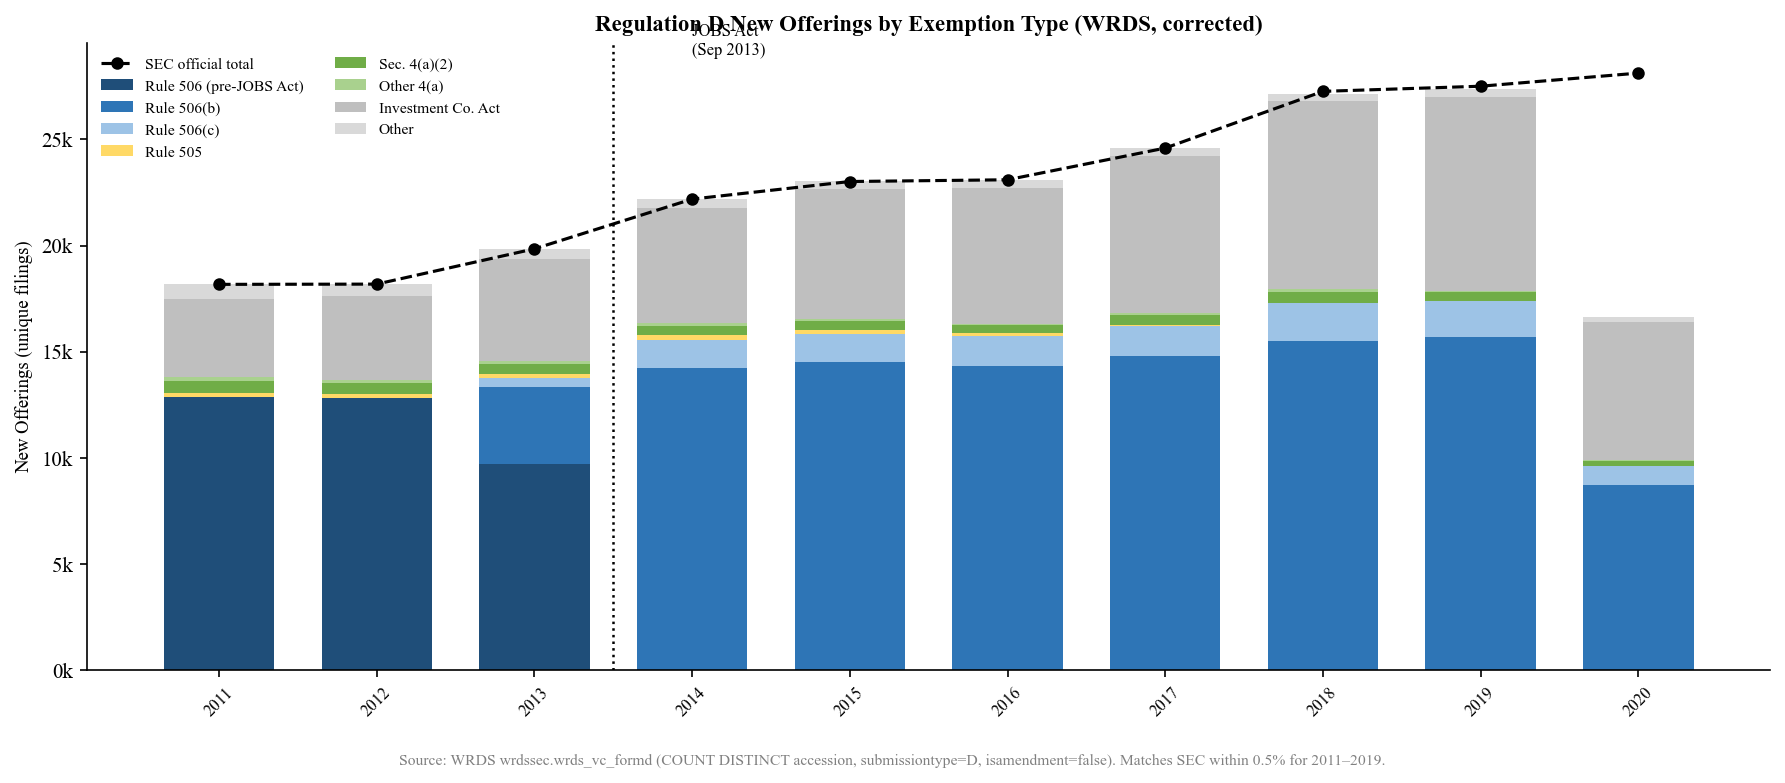

Saved to output/regd-plots/


In [8]:
item_label = {
    '06':   'Rule 506 (pre-JOBS Act)',
    '06b':  'Rule 506(b)',
    '06c':  'Rule 506(c)',
    '05':   'Rule 505',
    '04':   'Sec. 4(a)(2)',
    '04.1': 'Other 4(a)', '04.2': 'Other 4(a)', '04.3': 'Other 4(a)',
    '3C.1': 'Investment Co. Act', '3C.5': 'Investment Co. Act',
    '3C.7': 'Investment Co. Act', '3C.9': 'Investment Co. Act',
}
COLORS = {
    'Rule 506 (pre-JOBS Act)': '#1f4e79',
    'Rule 506(b)':             '#2e75b6',
    'Rule 506(c)':             '#9dc3e6',
    'Rule 505':                '#ffd966',
    'Sec. 4(a)(2)':           '#70ad47',
    'Other 4(a)':             '#a9d18e',
    'Investment Co. Act':     '#bfbfbf',
    'Other':                   '#d9d9d9',
}
COL_ORDER = list(COLORS.keys())

wrds_df['label'] = wrds_df['exempt_item'].map(item_label).fillna('Other')
pivot = wrds_df.groupby(['filing_year', 'label'])['new_offerings'].sum().unstack(fill_value=0)
years = list(range(2011, 2021))

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(years))
for col in COL_ORDER:
    if col in pivot.columns:
        vals = [pivot.loc[y, col] if y in pivot.index else 0 for y in years]
        ax.bar(years, vals, bottom=bottom, color=COLORS[col], label=col, width=0.7)
        bottom += np.array(vals, dtype=float)

ax.plot(years, [sec_official.get(y, 0) for y in years],
        'ko--', linewidth=1.5, markersize=5, label='SEC official total', zorder=5)
ax.axvline(2013.5, color='black', linestyle=':', linewidth=1.2)
ax.text(2014.0, 29000, 'JOBS Act\n(Sep 2013)', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Regulation D New Offerings by Exemption Type (WRDS, corrected)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('New Offerings (unique filings)', fontsize=9)
ax.legend(fontsize=7.5, frameon=False, loc='upper left', ncol=2)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=8)
fig.text(0.5, -0.03,
         'Source: WRDS wrdssec.wrds_vc_formd (COUNT DISTINCT accession, submissiontype=D, isamendment=false).'
         ' Matches SEC within 0.5% for 2011–2019.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
plt.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/formd_notebook_corrected.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved to output/regd-plots/')